In [354]:
import matplotlib.pyplot as plt
import numpy as np

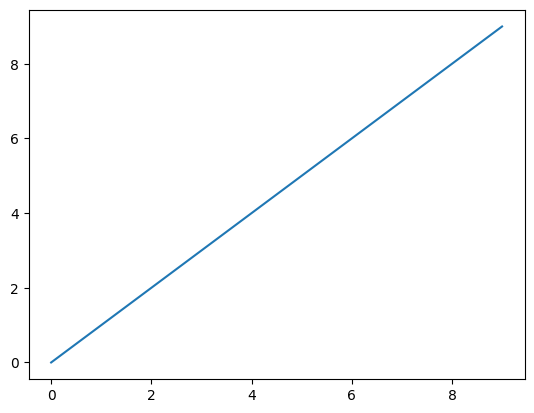

In [355]:
x = np.arange(0,10,1)
y = np.arange(0,10,1)
plt.plot(x,y)

In [356]:
near = 10
far = 1E8
viewz = np.linspace(near, far, 10000, endpoint=True)
viewz

array([1.00000000e+01, 1.00109991e+04, 2.00119982e+04, ...,
       9.99799980e+07, 9.99899990e+07, 1.00000000e+08])

# linear depth function

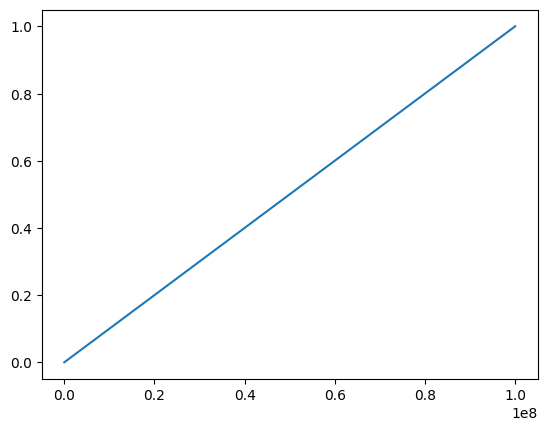

In [357]:
def linear_depth_func(viewz):
    return viewz / (far - near)

depth = linear_depth_func(viewz)
plt.plot(viewz, depth)

# log depth function
```
float frag_depth_log(float c, float far, float vz) {
    return log2(c * -vz + 1.0) / log2(c * far + 1.0);
}

float invLogFar = 1.0 / log2(uFar * logFactor + 1.0);
vLogDepth = log2(eyeZ * logFactor + 1.0) * invLogFar;
```

[1.00000000e+01 1.00109991e+04 2.00119982e+04 ... 9.99799980e+07
 9.99899990e+07 1.00000000e+08]
[9.99999900e+07 9.99899890e+07 9.99799880e+07 ... 2.00019982e+04
 1.00009991e+04 0.00000000e+00]
[0.00000000e+00 6.20513704e-06 1.24108947e-05 ... 5.28387078e-01
 5.71360368e-01 1.00000000e+00]


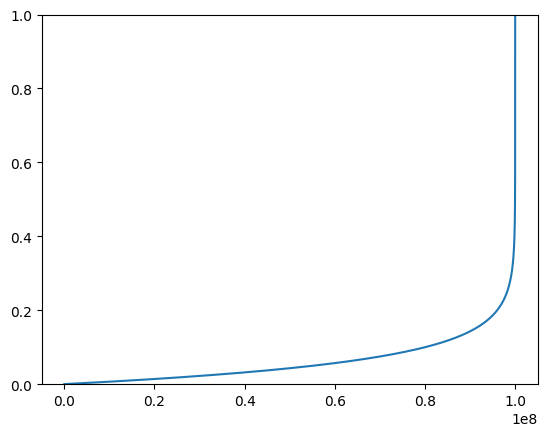

In [358]:
logFactor = 0.1

# def log_depth_func(c, far, z):
#     return 1 - np.log2(c * (far-z) + 1.0) / np.log2(c * far + 1.0)

def log_depth_func(c, near, far, z):
    z = z - near
    far = far - near
    invLogFar = 1.0 / np.log2(far * c + 1.0)
    return 1 - np.log2((far - z) * c + 1.0) * invLogFar

log_depth = log_depth_func(logFactor, near, far, viewz)
print(viewz)
print(far-viewz)
print(log_depth)
plt.ylim([0,1])
plt.plot(viewz, log_depth)

# range stretch depth func  

red: raw function; Green: target function


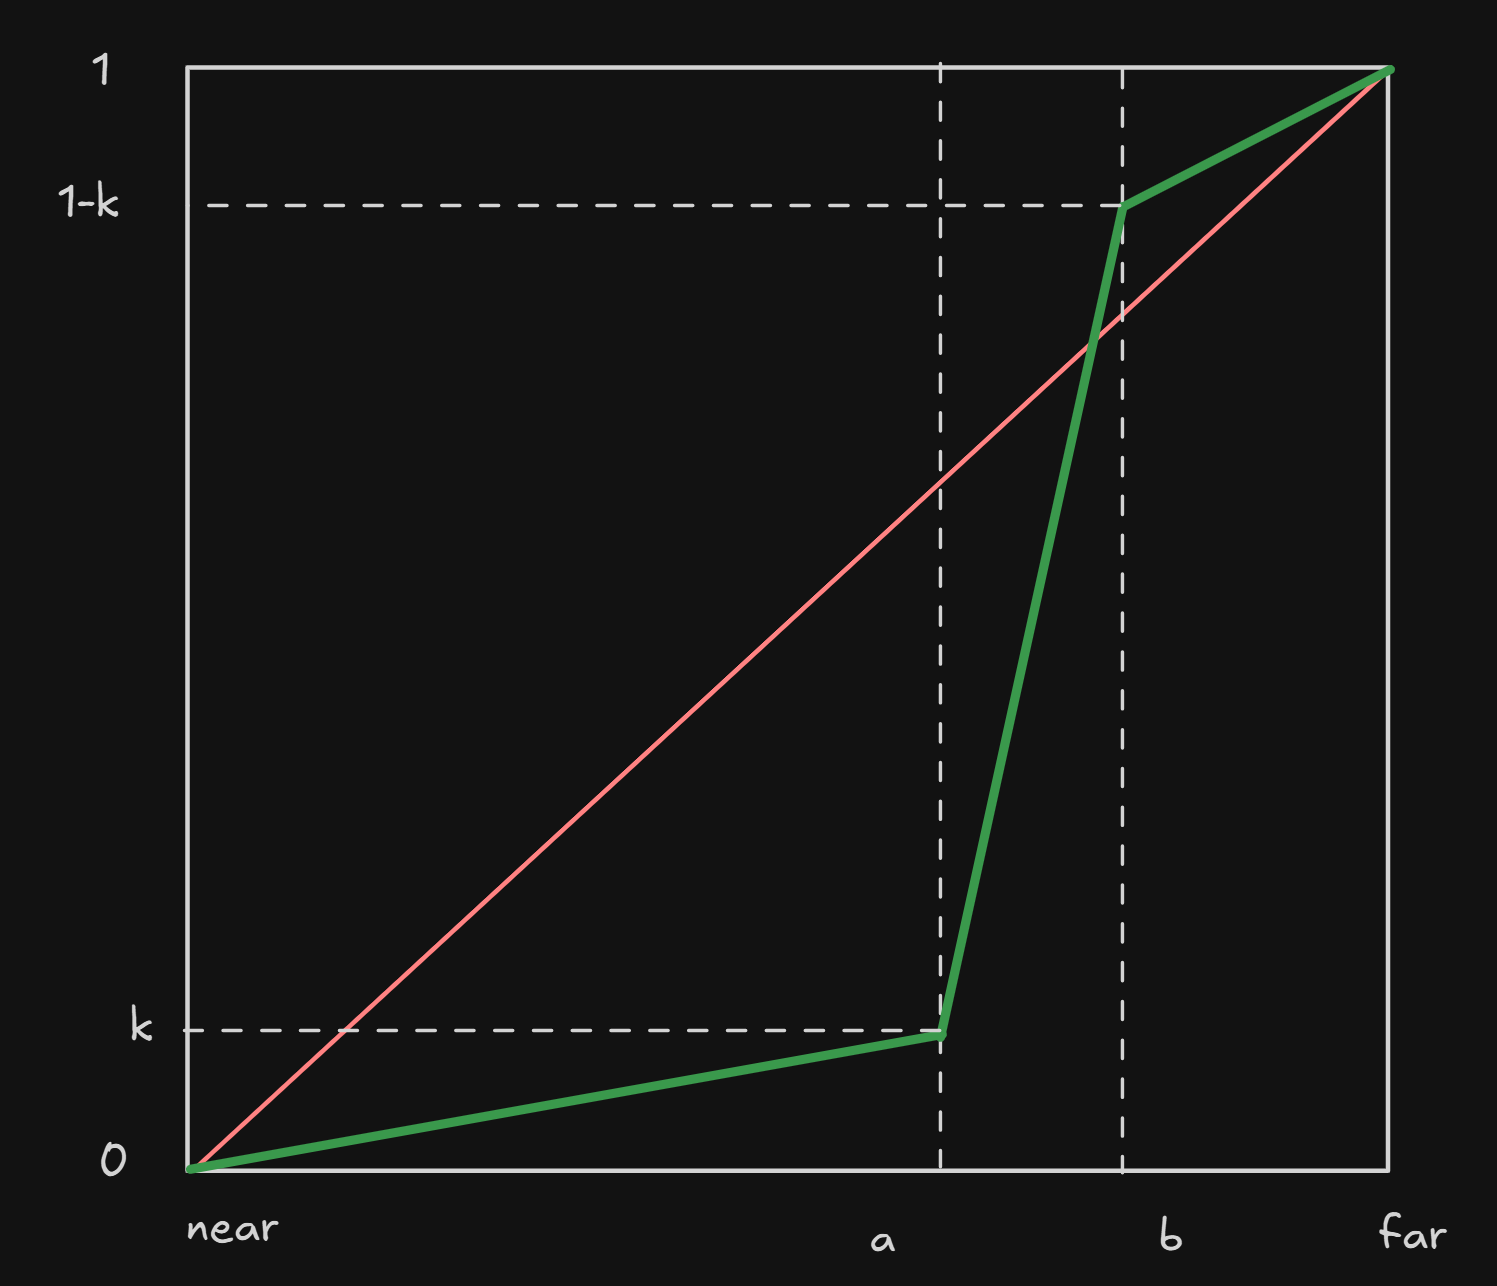

In [359]:
from IPython.display import Image
print("red: raw function; Green: target function")
Image("range_strech_depth_func.png", width=300, height=300)

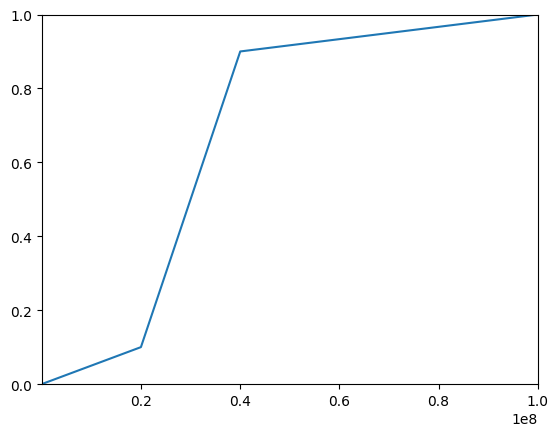

In [ ]:
# def range_stretch_depth_func(k, n, f, x, a, b):
#     x = x - n
#     f = f - n
#     k = f * k
#     y = np.copy(x)
#     xmin, xmax, ymin, ymax = 0, f, 0, f
    
#     y[x<a] = ymin + k / (a - xmin) * (x[x<a] - xmin)
#     y[(x>=a)&(x<=b)] = (ymin + k) + (ymax - ymin - 2*k) / (b - a) * (x[(x>=a)&(x<=b)] - a)
#     y[x>b] = (ymax - k) + k / (xmax - b) * (x[x>b] - b)
#     y = y / (ymax - ymin)
#     return y

def range_stretch_depth_func(k, n, f, x, a, b):
    x = x - n
    f = f - n
    k = f * k
    y = np.copy(x)
    
    y[x<a] = k / a * x[x<a]
    y[(x>=a)&(x<=b)] = k + (f - 2*k) / (b - a) * (x[(x>=a)&(x<=b)] - a)
    y[x>b] = (f - k) + k / (f - b) * (x[x>b] - b)
    y = y / f
    return y

near = 10
far = 1E8
viewz = np.linspace(near, far, 10000, endpoint=True)
viewz
k = 0.1
a = 0.2 * 1E8
b = 0.4 * 1E8

depth = range_stretch_depth_func(k, near, far, viewz, a, b)
plt.xlim([near,far])
plt.ylim([0,1])
plt.plot(viewz, depth)